# 6. Baseline Modelling

This notebook implements **baseline models** for revenue forecasting at the Business Subsegment level, organized in two main parts:

- **6.1 Time Series Models** — Classical TS approaches that operate on the raw Revenue/Orders series per subsegment.
- **6.2 Machine Learning Models** — ML models leveraging the full set of engineered features from Feature Selection.

---

**Target**: Revenue cons. (anon) — Orders used as leading indicator (not a target).  
**Granularity**: One model per TGL Business Subsegment (134 series).  
**Validation**: Train on periods 1–36, validate on 37–42 (6-period horizon).  
**Test**: Periods 43–48 (all targets NaN).  
**Metrics**: RMSE, MAE, wMAPE (weighted MAPE — robust to near-zero revenue subsegments), R² (coefficient of determination).  

**6.1 Time Series Models**: Naïve / Seasonal Naïve / Moving Average → SARIMA → VAR → Prophet → Chronos (zero-shot)  
**6.2 ML Models**: *(to be implemented)*

> **Note**: TS models (6.1) operate on the raw Revenue/Orders series per subsegment. Categorical columns serve as **grouping keys**. ML models (6.2) leverage the 100 engineered features from Feature Selection.

In [1]:
import os, sys
import time

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import xgboost as xgb


# Register DLL directories BEFORE any heavy imports (fixes WinError 127 with torch on Windows)
if os.name == 'nt':
    _lib_bin = os.path.join(sys.prefix, 'Library', 'bin')
    if os.path.isdir(_lib_bin):
        os.environ['PATH'] = _lib_bin + os.pathsep + os.environ.get('PATH', '')
        if hasattr(os, 'add_dll_directory'):
            try: os.add_dll_directory(_lib_bin)
            except OSError: pass
    import importlib.util as _ilu
    _spec = _ilu.find_spec('torch')
    if _spec and _spec.origin:
        for _subdir in ('lib', 'bin'):
            _d = os.path.join(os.path.dirname(_spec.origin), _subdir)
            if os.path.isdir(_d):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
                if hasattr(os, 'add_dll_directory'):
                    try: os.add_dll_directory(_d)
                    except OSError: pass

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Sklearn — preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

# Baseline models
from src.code.baseline_models import (
    get_subsegment_series, get_valid_subsegments,
    compute_metrics, evaluate_model,
    run_naive_baselines, run_sarima, run_var, run_prophet, run_chronos,
    plot_model_comparison, plot_actual_vs_predicted
)

print('All imports successful.')

All imports successful.


## 6.0 Data Loading

In [2]:
data_dir = '../data/features'

train_full = pd.read_parquet(os.path.join(data_dir, 'training_subsegment_fs.parquet'))
test_df    = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment_fs.parquet'))

TARGET     = 'Revenue cons. (anon)'
ORDERS_COL = 'Orders cons. (anon)'
PERIOD_COL = 'Anon Period'
SUBSEG_COL = 'TGL Business Subsegment'
ID_COLS    = ['Anon Period', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']

print(f'Training:   {train_full.shape}  |  Periods: {train_full[PERIOD_COL].min()}–{train_full[PERIOD_COL].max()}')
print(f'Test:       {test_df.shape}  |  Periods: {test_df[PERIOD_COL].min()}–{test_df[PERIOD_COL].max()}')
print(f'Unique subsegments: {train_full[SUBSEG_COL].nunique()}')

Training:   (4237, 106)  |  Periods: 1–42
Test:       (715, 106)  |  Periods: 43–48
Unique subsegments: 134


## 6.0.1 Internal Validation Split

The test set (periods 43–48) has all targets as NaN. We create an internal temporal split from training data:
- **Train**: periods 1–36
- **Validation**: periods 37–42 (mimics the 6-period test horizon)

In [3]:
VAL_CUTOFF = 36
HORIZON    = 6

train_df = train_full[train_full[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df   = train_full[train_full[PERIOD_COL] > VAL_CUTOFF].copy()

subsegments = get_valid_subsegments(train_df, TARGET)

# Series length diagnostics
lengths = [len(get_subsegment_series(train_df, s, PERIOD_COL, TARGET).dropna()) for s in subsegments]

print(f'Internal train: {train_df.shape} — periods {train_df[PERIOD_COL].min()}–{train_df[PERIOD_COL].max()}')
print(f'Internal val:   {val_df.shape} — periods {val_df[PERIOD_COL].min()}–{val_df[PERIOD_COL].max()}')
print(f'\nSubsegments with revenue data: {len(subsegments)}')
print(f'Series lengths — min: {min(lengths)}, median: {np.median(lengths):.0f}, max: {max(lengths)}')
print(f'Series with ≥ 24 points (seasonal SARIMA): {sum(l >= 24 for l in lengths)}')
print(f'Series with < 12 points: {sum(l < 12 for l in lengths)}')

Internal train: (3524, 106) — periods 1–36
Internal val:   (713, 106) — periods 37–42

Subsegments with revenue data: 117
Series lengths — min: 2, median: 36, max: 36
Series with ≥ 24 points (seasonal SARIMA): 93
Series with < 12 points: 12


---

## 6.1 Time Series Models

### 6.1.1 Naïve Baselines

Minimum performance bar — any model must beat these.

| Baseline | Logic |
|----------|-------|
| **Naïve** | $\\hat{y}_t = y_{t-1}$ |
| **Seasonal Naïve** | $\\hat{y}_t = y_{t-12}$ |
| **Moving Average** | $\\hat{y}_t = \\text{mean}(y_{t-1}, ..., y_{t-k})$ |

In [4]:
naive_all = run_naive_baselines(subsegments, train_df, val_df, PERIOD_COL, TARGET)

baseline_metrics = []
for name, res in naive_all.items():
    metrics = evaluate_model(res, val_df, PERIOD_COL, TARGET, name)
    baseline_metrics.append(metrics)
    print(f"{name:20s} — RMSE: {metrics['RMSE']:>14,.0f} | MAE: {metrics['MAE']:>14,.0f} | wMAPE: {metrics['wMAPE']:.1f}%")

print(f'\nBaselines computed for {len(naive_all["Naïve"])} subsegments.')

Naïve                — RMSE:     20,881,478 | MAE:      9,968,088 | wMAPE: 26.0%
Seasonal Naïve       — RMSE:     12,800,528 | MAE:      5,346,114 | wMAPE: 14.0%
Moving Avg (3)       — RMSE:     11,403,219 | MAE:      5,406,896 | wMAPE: 14.1%
Moving Avg (6)       — RMSE:      9,709,532 | MAE:      4,588,482 | wMAPE: 12.0%

Baselines computed for 110 subsegments.


---

### 6.1.2 SARIMA

SARIMA models a single univariate series per subsegment. Uses pmdarima.auto_arima for automatic (p,d,q)×(P,D,Q,m) selection. Seasonal period m=12 if ≥24 data points.

\\phi(B)\\Phi(B^{12})(1-B)^d(1-B^{12})^D y_t = \\theta(B)\\Theta(B^{12})\\epsilon_t

In [5]:
sarima_results, sarima_errors = run_sarima(subsegments, train_df, val_df, PERIOD_COL, TARGET)

sarima_metrics = evaluate_model(sarima_results, val_df, PERIOD_COL, TARGET, 'SARIMA')
print(f"SARIMA — RMSE: {sarima_metrics['RMSE']:,.0f} | MAE: {sarima_metrics['MAE']:,.0f} | wMAPE: {sarima_metrics['wMAPE']:.1f}% | R²: {sarima_metrics['R2']:.4f}")

  SARIMA progress: 25/117 subsegments...
  SARIMA progress: 50/117 subsegments...
  SARIMA progress: 75/117 subsegments...
  SARIMA progress: 100/117 subsegments...

SARIMA fitted for 105 subsegments. Errors: 2
SARIMA — RMSE: 14,774,150 | MAE: 5,923,012 | wMAPE: 15.3% | R²: 0.9538


---

### 6.1.3 VAR — Vector Autoregression

VAR captures the interaction between Revenue and Orders (leading indicator).

\\mathbf{y}_t = \\mathbf{c} + \\sum_{i=1}^{p} \\mathbf{A}_i \\mathbf{y}_{t-i} + \\mathbf{u}_t \\quad \\text{where } \\mathbf{y}_t = [\\text{Revenue}_t, \\text{Orders}_t]^\\top

In [6]:
var_results, var_errors = run_var(subsegments, train_df, val_df, PERIOD_COL, TARGET, ORDERS_COL)

var_metrics = evaluate_model(var_results, val_df, PERIOD_COL, TARGET, 'VAR')
print(f"VAR — RMSE: {var_metrics['RMSE']:,.0f} | MAE: {var_metrics['MAE']:,.0f} | wMAPE: {var_metrics['wMAPE']:.1f}% | R²: {var_metrics['R2']:.4f}")

  VAR progress: 25/117 subsegments...
  VAR progress: 50/117 subsegments...
  VAR progress: 75/117 subsegments...
  VAR progress: 100/117 subsegments...

VAR fitted for 89 subsegments. Errors: 11
VAR — RMSE: 16,254,747 | MAE: 7,348,745 | wMAPE: 16.2% | R²: 0.9493


---

### 6.1.4 Facebook Prophet

Auto-decomposes series into trend + seasonality. changepoint_prior_scale=0.01 to reduce overfitting (professor's advice).

y(t) = g(t) + s(t) + h(t) + \\epsilon_t

In [7]:
prophet_results, prophet_errors = run_prophet(subsegments, train_df, val_df, PERIOD_COL, TARGET)

prophet_metrics = evaluate_model(prophet_results, val_df, PERIOD_COL, TARGET, 'Prophet')
print(f"Prophet — RMSE: {prophet_metrics['RMSE']:,.0f} | MAE: {prophet_metrics['MAE']:,.0f} | wMAPE: {prophet_metrics['wMAPE']:.1f}% | R²: {prophet_metrics['R2']:.4f}")

  Prophet progress: 25/117 subsegments...
  Prophet progress: 50/117 subsegments...
  Prophet progress: 75/117 subsegments...
  Prophet progress: 100/117 subsegments...

Prophet fitted for 107 subsegments. Errors: 0
Prophet — RMSE: 12,154,381 | MAE: 5,770,040 | wMAPE: 14.9% | R²: 0.9683


---

### 6.1.5 Amazon Chronos (Zero-Shot Transformer)

Foundation model pre-trained on millions of time series — **no training needed**. We feed each subsegment's history and get forecasts. Uses mazon/chronos-t5-small.

> ⚠️ Requires PyTorch. If torch has DLL issues in your conda environment, this section will be skipped gracefully.

In [8]:
chronos_results, chronos_errors = run_chronos(subsegments, train_df, val_df, PERIOD_COL, TARGET)

if chronos_results:
    chronos_metrics = evaluate_model(chronos_results, val_df, PERIOD_COL, TARGET, 'Chronos (Zero-Shot)')
    print(f"Chronos — RMSE: {chronos_metrics['RMSE']:,.0f} | MAE: {chronos_metrics['MAE']:,.0f} | wMAPE: {chronos_metrics['wMAPE']:.1f}% | R²: {chronos_metrics['R2']:.4f}")
else:
    chronos_metrics = {'Model': 'Chronos (Zero-Shot)', 'RMSE': np.nan, 'MAE': np.nan, 'wMAPE': np.nan, 'R2': np.nan}
    print('Chronos skipped — see errors above.')

⚠️ Chronos unavailable: No module named 'torch'
  Skipping Chronos — install torch + chronos-forecasting to enable.
Chronos skipped — see errors above.


---

### 6.1.6 Time Series Model Comparison

In [9]:
all_metrics = baseline_metrics + [sarima_metrics, var_metrics, prophet_metrics, chronos_metrics]
comparison_df = pd.DataFrame(all_metrics)[['Model', 'RMSE', 'MAE', 'wMAPE', 'R2']]
comparison_df = comparison_df.sort_values('RMSE').reset_index(drop=True)

print('=' * 72)
print('MODEL COMPARISON — Validation (Periods 37–42)')
print('=' * 72)

comparison_df.style.format(
    {'RMSE': '{:,.0f}', 'MAE': '{:,.0f}', 'wMAPE': '{:.1f}%', 'R2': '{:.4f}'}
).highlight_min(subset=['RMSE', 'MAE', 'wMAPE'], color='green').highlight_max(subset=['R2'], color='green')

MODEL COMPARISON — Validation (Periods 37–42)


,Model,RMSE,MAE,wMAPE,R2
0,Moving Avg (6),"9,709,532","4,588,482",12.0%,0.9796
1,Moving Avg (3),"11,403,219","5,406,896",14.1%,0.9719
2,Prophet,"12,154,381","5,770,040",14.9%,0.9683
3,Seasonal Naïve,"12,800,528","5,346,114",14.0%,0.9645
4,SARIMA,"14,774,150","5,923,012",15.3%,0.9538
5,VAR,"16,254,747","7,348,745",16.2%,0.9493
6,Naïve,"20,881,478","9,968,088",26.0%,0.9056
7,Chronos (Zero-Shot),nan,nan,nan%,nan


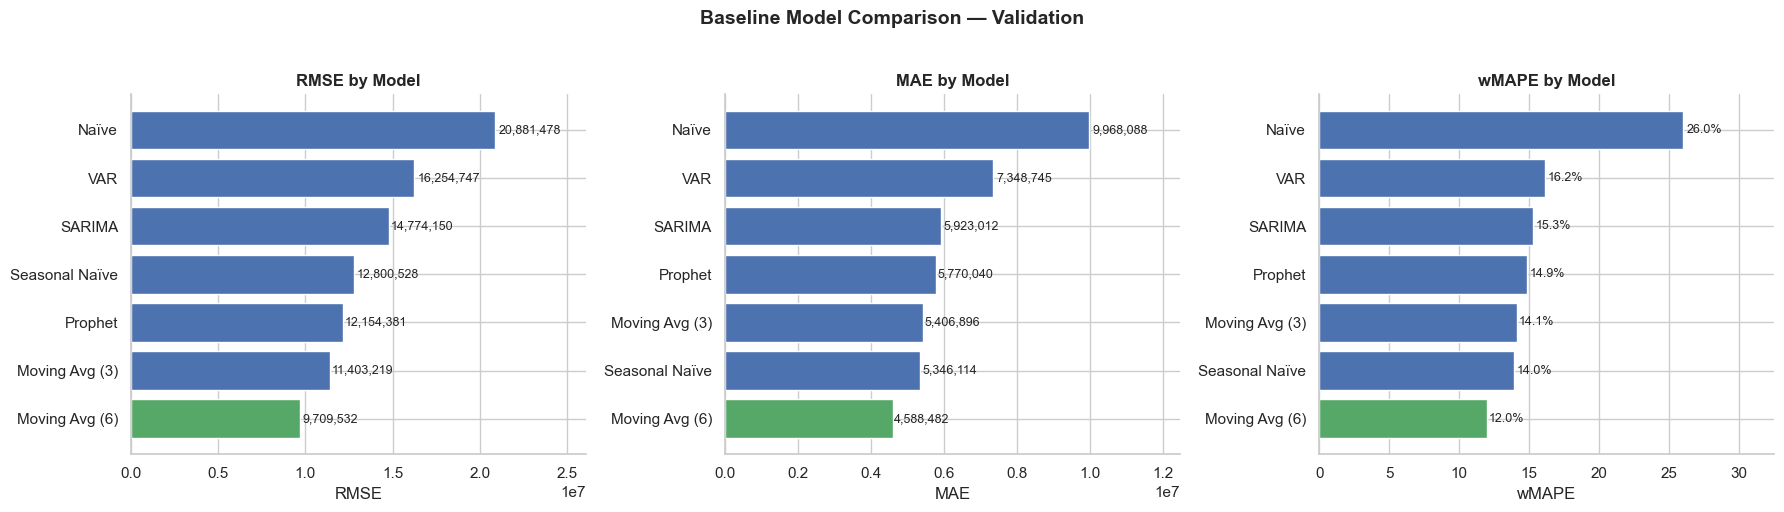

In [10]:
plot_model_comparison(comparison_df)

#### Actual vs Predicted — Representative Subsegments

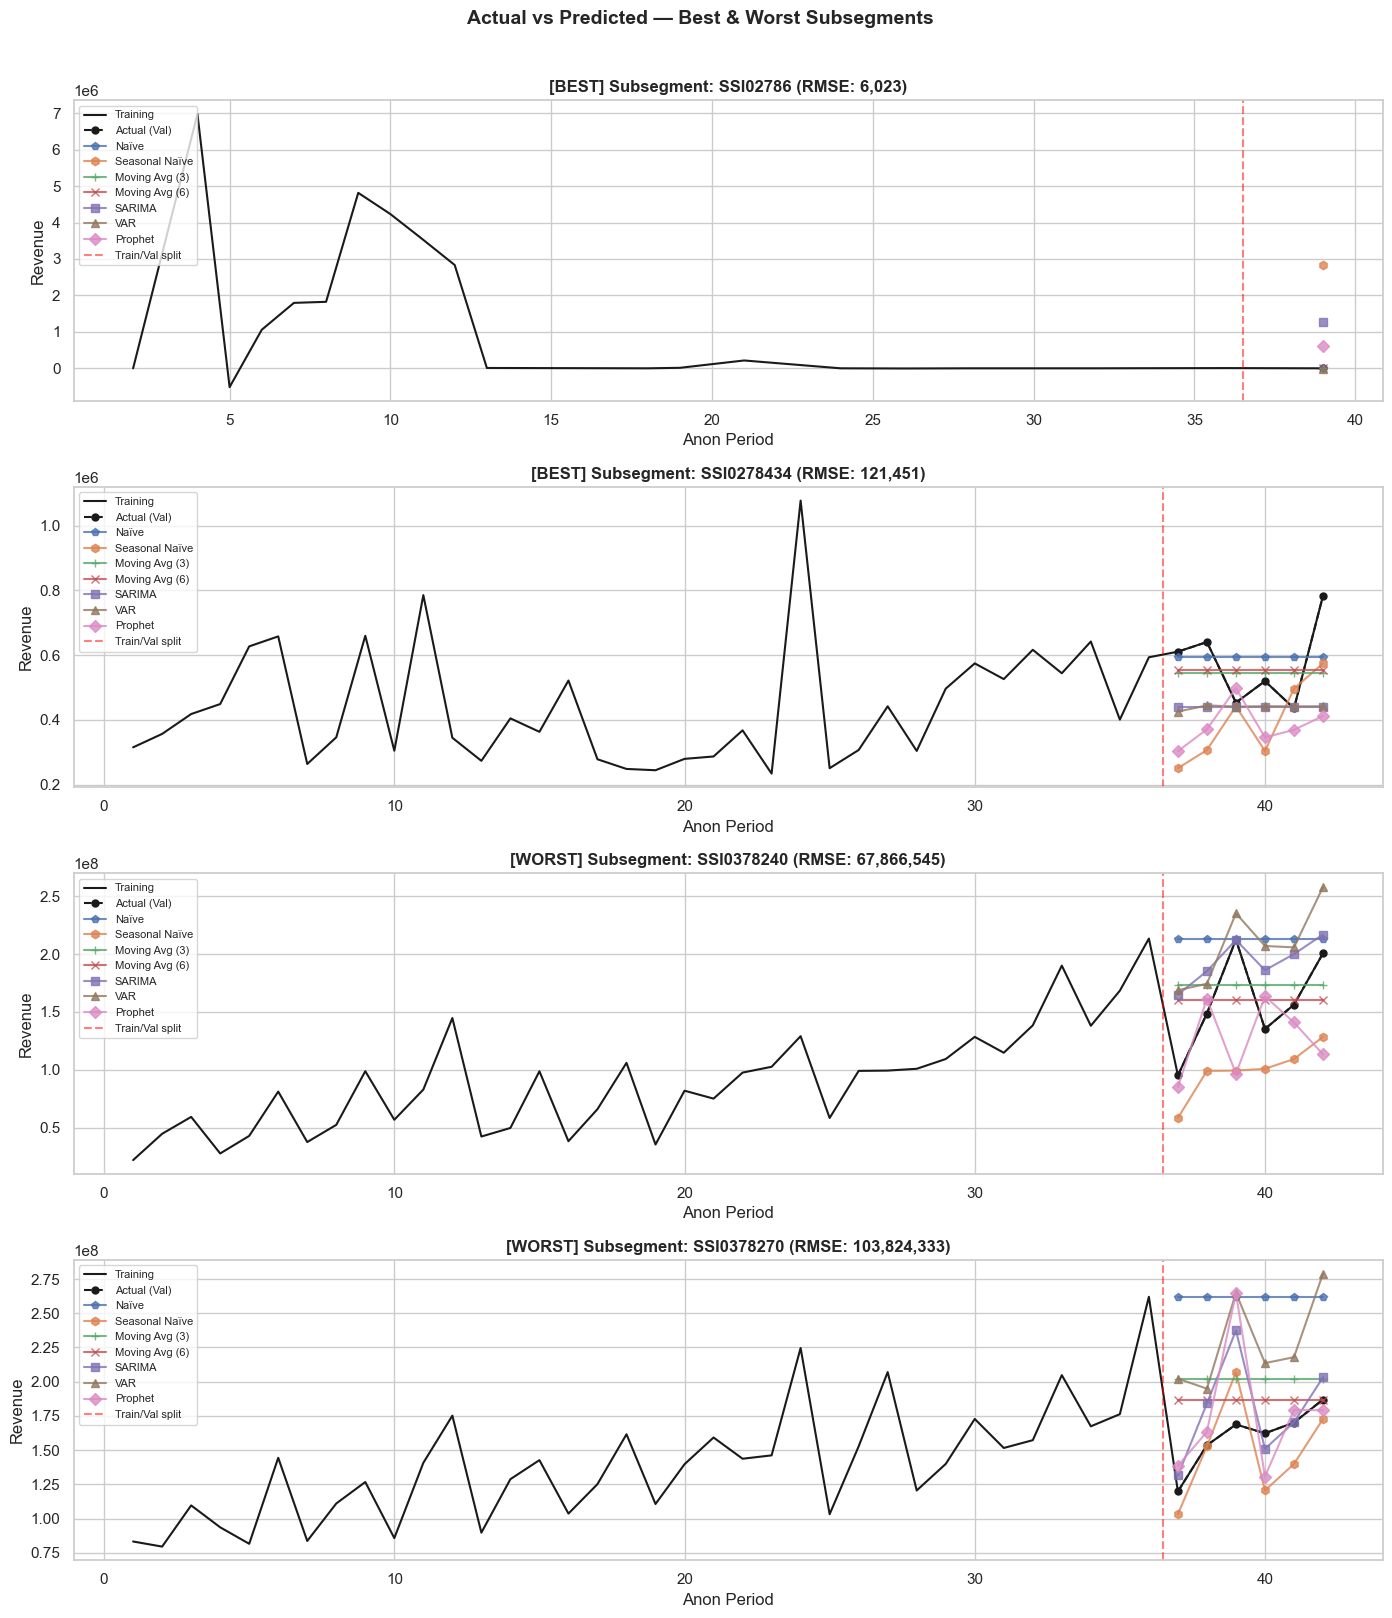

In [11]:
# Combine all model results for the comparison plot
all_results = {}
all_results.update(naive_all)  # Naïve, Seasonal Naïve, Moving Avg (3), Moving Avg (6)
all_results['SARIMA'] = sarima_results
all_results['VAR'] = var_results
all_results['Prophet'] = prophet_results
if chronos_results:
    all_results['Chronos (Zero-Shot)'] = chronos_results

plot_actual_vs_predicted(all_results, train_full, val_df, PERIOD_COL, TARGET, VAL_CUTOFF)

---

### 6.1.7 Baseline Summary

- **Naïve baselines** establish the minimum performance bar
- **SARIMA** models univariate seasonal patterns per subsegment
- **VAR** captures Revenue–Orders lead-lag dynamics (bivariate)
- **Prophet** auto-decomposes trend + seasonality
- **Chronos** provides zero-shot forecasting from a pre-trained transformer

> ℹ️ These baselines are **univariate/bivariate** — they do not use the full 100-feature set. The next section prepares the pipeline for ML models that leverage all features.

In [12]:
print('\n' + '=' * 72)
print('FINAL BASELINE RESULTS')
print('=' * 72)
print(comparison_df.to_string(index=False))
print(f'\nBest model by RMSE: {comparison_df.iloc[0]["Model"]}')


FINAL BASELINE RESULTS
              Model         RMSE          MAE     wMAPE       R2
     Moving Avg (6) 9.709532e+06 4.588482e+06 11.973316 0.979592
     Moving Avg (3) 1.140322e+07 5.406896e+06 14.108909 0.971852
            Prophet 1.215438e+07 5.770040e+06 14.868039 0.968296
     Seasonal Naïve 1.280053e+07 5.346114e+06 13.950303 0.964531
             SARIMA 1.477415e+07 5.923012e+06 15.301587 0.953799
                VAR 1.625475e+07 7.348745e+06 16.162206 0.949301
              Naïve 2.088148e+07 9.968088e+06 26.011013 0.905611
Chronos (Zero-Shot)          NaN          NaN       NaN      NaN

Best model by RMSE: Moving Avg (6)


---

## 6.2 Machine Learning Models

This section benchmarks ML models for revenue forecasting using **recursive multi-step prediction** to avoid data leakage.

**Key design decisions:**
- **Orders/ASP features dropped** — the test set (periods 43–48) has neither Orders nor Revenue, so any feature derived from these is unusable at inference time.
- **Recursive forecasting** — lag features are recomputed at each prediction step using only past actuals + previous predictions. Direct prediction with pre-computed lags would leak future Revenue values through the lag columns.
- **Two hierarchy levels** — Subsegment (bottom-up, ~100 series) and Segment (middle-out, ~24 series).

### 6.2.0 Imports & Configuration

In [13]:
from src.code.functions_models import *

# Column aliases (from defaults in functions_models.py)
TARGET     = DEFAULT_TARGET
ORDERS_COL = DEFAULT_ORDERS_COL
PERIOD_COL = DEFAULT_PERIOD_COL
SUBSEG_COL = DEFAULT_SUBSEG_COL
SEG_COL    = DEFAULT_SEG_COL
BU_COL     = DEFAULT_BU_COL

VAL_CUTOFF = 36   # Train: periods 1-36, Validation: periods 37-42
HORIZON    = 6    # 6-period forecast horizon (matches test set)

print(f'Train:      periods 1-{VAL_CUTOFF}')
print(f'Validation: periods {VAL_CUTOFF+1}-{VAL_CUTOFF+HORIZON}')
print(f'Test:       periods 43-48 (targets unknown)')

Train:      periods 1-36
Validation: periods 37-42
Test:       periods 43-48 (targets unknown)


### 6.2.1 Feature Preparation

Prepare subsegment-level features:
- Drop raw targets (Revenue, Orders) and period column
- Drop all Orders/ASP-derived features (unavailable at test time)
- Keep categorical hierarchy columns for tree-based models
- No scaling/imputation here (handled per-model in the training pipeline)

In [14]:
# Prepare subsegment-level data
X_train, y_train, X_val, y_val, feature_cols, cat_cols = prepare_subsegment_data(
    df=train_full,
    val_cutoff=VAL_CUTOFF
)

print(f'Train shape: {X_train.shape}')
print(f'Val shape:   {X_val.shape}')
print(f'Features:    {len(feature_cols)} (was ~103 before dropping Orders/ASP)')
print(f'Categoricals: {cat_cols}')

Train shape: (3524, 54)
Val shape:   (713, 54)
Features:    54 (was ~103 before dropping Orders/ASP)
Categoricals: ['TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']


### 6.2.2 Leakage Diagnostic

Every feature falls into one of these buckets:
- **Recomputed** — Revenue-based lags/rolling features that will be recomputed recursively at each forecast step
- **Static** — macro/temporal features that don't depend on the target (safe as-is)
- **Identity** — categorical hierarchy columns (safe)
- **Orders/ASP** — should have been dropped already (alert if present)
- **Unknown** — requires manual verification

In [15]:
coverage = diagnose_feature_coverage(feature_cols)

FEATURE COVERAGE DIAGNOSTIC
  Recomputed (leak-free) :  39
  Static (safe as-is)    :  12
  Identity (ID columns)  :   3
  UNKNOWN (check these!) :   0
------------------------------------------------------------

All features accounted for. Pipeline is clean.


### 6.2.3 Recursive Forecasting Engine

**Why recursive instead of direct?**

The pre-computed lag features in the parquet files use actual Revenue for ALL periods, including validation. For example, `Rev_Lag_1` at period 38 contains the actual Revenue from period 37 — which is a validation target. This is **data leakage**.

**Recursive approach:**
1. Train the model on periods 1–36 (lags computed from actuals — safe)
2. Predict period 37 → store predictions as "pseudo-actuals"
3. Recompute lags for period 38 using actuals (≤36) + prediction (37)
4. Predict period 38 → store, recompute for 39, and so on...

This ensures the model never sees future Revenue values during evaluation.

### 6.2.4 Model Definitions

| Model             | Type          | Handles NaN | Handles Categoricals | Notes                          |
|:------------------|:--------------|:-----------:|:--------------------:|:-------------------------------|
| LightGBM          | Boosting      | Yes         | Yes (native)         | Fast, strong baseline          |
| XGBoost           | Boosting      | Yes         | Yes (enable_categorical) | Robust alternative         |
| CatBoost          | Boosting      | Yes         | Yes (ordered encoding) | Good with categoricals       |
| Ridge             | Linear (L2)   | No          | No (dropped)         | Drops cats, numeric only       |
| Lasso             | Linear (L1)   | No          | No (dropped)         | Feature selection via L1       |
| ElasticNet        | Linear (L1+L2)| No          | No (dropped)         | Best of Ridge + Lasso          |
| Random Forest     | Bagging       | No          | No (dropped)         | Ensemble sanity check          |
| Gradient Boosting | Boosting      | No          | No (dropped)         | sklearn exact-split boosting   |

> **Note:** Linear models and sklearn tree models drop categorical columns entirely because integer-coding them as continuous features produces nonsensical results for regression.

In [16]:
models = get_models(cat_cols, feature_cols)
print(f'{len(models)} models loaded:')
for name, (mdl, needs_pp) in models.items():
    print(f'  {name:20s} | preprocessing: {needs_pp}')

7 models loaded:
  LightGBM             | preprocessing: False
  XGBoost              | preprocessing: False
  Ridge                | preprocessing: True
  Lasso                | preprocessing: True
  ElasticNet           | preprocessing: True
  Random Forest        | preprocessing: True
  Gradient Boosting    | preprocessing: True


### 6.2.5 Subsegment-Level Benchmarking (Recursive Forecast)

Run all models with recursive forecasting on validation periods 37–42.
Each model is trained on periods 1–36 and evaluated step-by-step.

In [20]:
print('=' * 72)
print('SUBSEGMENT-LEVEL BENCHMARKING (Recursive Forecast)')
print('=' * 72)


group_cols_sub = [DEFAULT_BU_COL, DEFAULT_SEG_COL, DEFAULT_SUBSEG_COL]

results_subseg = run_recursive_benchmark(
    train_full=train_full,
    val_cutoff=VAL_CUTOFF,
    feature_cols=feature_cols,
    cat_cols=cat_cols,
    level_name='Subsegment',
    group_cols=group_cols_sub
)

results_subseg_df = pd.DataFrame(results_subseg).sort_values('RMSE')
results_subseg_df

SUBSEGMENT-LEVEL BENCHMARKING (Recursive Forecast)
  LightGBM @ Subsegment ... RMSE:     36,315,932 | 1.7s
  XGBoost @ Subsegment ... RMSE:     25,851,766 | 2.2s
  Ridge @ Subsegment ... RMSE:  1,962,063,930 | 0.6s
  Lasso @ Subsegment ... RMSE:  1,962,064,358 | 1.0s
  ElasticNet @ Subsegment ... RMSE:  1,961,896,970 | 0.6s
  Random Forest @ Subsegment ... RMSE:     81,658,167 | 2.4s
  Gradient Boosting @ Subsegment ... RMSE:     54,543,064 | 10.7s


,Model,Level,RMSE,MAE,wMAPE,R2,N_samples,Time (s)
1,XGBoost,Subsegment,2.585177e+07,1.929453e+07,56.568309,0.842452,713,2.2
0,LightGBM,Subsegment,3.631593e+07,1.990967e+07,58.371789,0.689095,713,1.7
6,Gradient Boosting,Subsegment,5.454306e+07,4.307689e+07,126.294153,0.298687,713,10.7
5,Random Forest,Subsegment,8.165817e+07,7.219536e+07,211.664581,-0.571927,713,2.4
4,ElasticNet,Subsegment,1.961897e+09,1.921546e+09,5633.647620,-906.372178,713,0.6
2,Ridge,Subsegment,1.962064e+09,1.922049e+09,5635.123314,-906.526622,713,0.6
3,Lasso,Subsegment,1.962064e+09,1.922053e+09,5635.133998,-906.527018,713,1.0


### 6.2.6 Segment-Level Benchmarking

Aggregate subsegment data to segment level (~24 series), re-engineer lag features at segment granularity, and benchmark the same models.

**Important:** `build_segment_level_data()` computes lags from the full dataset. This means validation-period lags contain future information — which is exactly why we use **recursive forecasting** to recompute them at prediction time.

In [18]:
# Build segment-level dataset
seg_df = build_segment_level_data(train_full)


# Prepare segment-level train/val split
X_tr_seg, y_tr_seg, X_va_seg, y_va_seg, feat_seg, cat_seg = prepare_segment_data(
    seg_df=seg_df,
    val_cutoff=VAL_CUTOFF
)

print(f'Segment train: {X_tr_seg.shape}, val: {X_va_seg.shape}')
print(f'Features: {len(feat_seg)}')

Segment-level dataset: (4032, 30)
Segment train: (3456, 26), val: (576, 26)
Features: 26


In [19]:
print('=' * 72)
print('SEGMENT-LEVEL BENCHMARKING (Recursive Forecast)')
print('=' * 72)

# Definimos as colunas que identificam um Segmento (BU + Segmento)
group_cols_seg = [DEFAULT_BU_COL, DEFAULT_SEG_COL]

results_seg = run_recursive_benchmark(
    train_full=seg_df,
    val_cutoff=VAL_CUTOFF,
    feature_cols=feat_seg,
    cat_cols=cat_seg,
    level_name='Segment',
    group_cols=group_cols_seg
)

results_seg_df = pd.DataFrame(results_seg).sort_values('RMSE')
results_seg_df

SEGMENT-LEVEL BENCHMARKING (Recursive Forecast)
  LightGBM @ Segment ... RMSE:      9,959,013 | 0.9s
  XGBoost @ Segment ... RMSE:     12,757,145 | 0.9s
  Ridge @ Segment ... RMSE:     16,245,351 | 0.3s
  Lasso @ Segment ... RMSE:     16,251,325 | 0.4s
  ElasticNet @ Segment ... RMSE:     16,238,274 | 0.4s
  Random Forest @ Segment ... RMSE:     20,353,108 | 0.7s
  Gradient Boosting @ Segment ... RMSE:     11,897,709 | 1.9s


,Model,Level,RMSE,MAE,wMAPE,R2,N_samples,Time (s)
0,LightGBM,Segment,9.959013e+06,2.508468e+06,5.942482,0.996368,576,0.9
6,Gradient Boosting,Segment,1.189771e+07,3.184620e+06,7.544265,0.994816,576,1.9
1,XGBoost,Segment,1.275714e+07,2.100712e+06,4.976522,0.994040,576,0.9
4,ElasticNet,Segment,1.623827e+07,4.860915e+06,11.515355,0.990344,576,0.4
2,Ridge,Segment,1.624535e+07,5.136690e+06,12.168656,0.990336,576,0.3
3,Lasso,Segment,1.625132e+07,5.125569e+06,12.142311,0.990329,576,0.4
5,Random Forest,Segment,2.035311e+07,4.835996e+06,11.456324,0.984830,576,0.7


### 6.2.7 Full Model Comparison

Combined benchmarking table across all models and hierarchy levels.
Sorted by RMSE (primary metric). All results use leak-free recursive forecasting.

In [21]:
# Combine all results
all_ml_results = results_subseg + results_seg

# Add TS baselines from section 6.1 for comparison
ts_baselines = comparison_df.copy()
ts_baselines['Level'] = 'TS Baseline'
ts_baselines['Time (s)'] = 0
ts_baselines['N_samples'] = 0

benchmark_df = pd.concat([
    pd.DataFrame(all_ml_results),
    ts_baselines[['Model', 'Level', 'RMSE', 'MAE', 'wMAPE', 'R2', 'N_samples', 'Time (s)']]
], ignore_index=True).sort_values('RMSE').reset_index(drop=True)

print('=' * 72)
print('FULL MODEL COMPARISON — Validation (Periods 37-42)')
print('All ML models evaluated with recursive forecasting (no leakage)')
print('=' * 72)

display_cols = ['Model', 'Level', 'RMSE', 'MAE', 'wMAPE', 'R2']
print(benchmark_df[display_cols].to_string(
    index=False,
    formatters={
        'RMSE':  lambda x: f'{x:>14,.0f}' if not np.isnan(x) else '-',
        'MAE':   lambda x: f'{x:>14,.0f}' if not np.isnan(x) else '-',
        'wMAPE': lambda x: f'{x:.1f}%' if not np.isnan(x) else '-',
        'R2':    lambda x: f'{x:.4f}' if not np.isnan(x) else '-',
    }
))

best = benchmark_df.iloc[0]
print(f'\nBest model: {best["Model"]} ({best["Level"]}) — RMSE: {best["RMSE"]:,.0f} | R²: {best["R2"]:.4f}')

FULL MODEL COMPARISON — Validation (Periods 37-42)
All ML models evaluated with recursive forecasting (no leakage)
              Model       Level           RMSE            MAE   wMAPE        R2
     Moving Avg (6) TS Baseline      9,709,532      4,588,482   12.0%    0.9796
           LightGBM     Segment      9,959,013      2,508,468    5.9%    0.9964
     Moving Avg (3) TS Baseline     11,403,219      5,406,896   14.1%    0.9719
  Gradient Boosting     Segment     11,897,709      3,184,620    7.5%    0.9948
            Prophet TS Baseline     12,154,381      5,770,040   14.9%    0.9683
            XGBoost     Segment     12,757,145      2,100,712    5.0%    0.9940
     Seasonal Naïve TS Baseline     12,800,528      5,346,114   14.0%    0.9645
             SARIMA TS Baseline     14,774,150      5,923,012   15.3%    0.9538
         ElasticNet     Segment     16,238,274      4,860,915   11.5%    0.9903
              Ridge     Segment     16,245,351      5,136,690   12.2%    0.9903
     

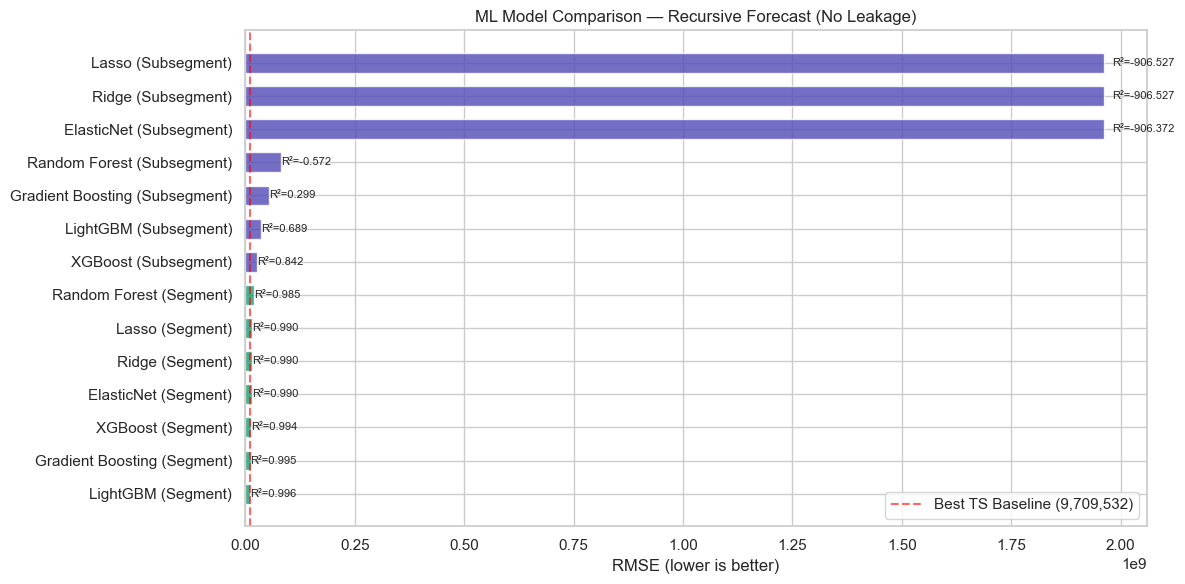

In [22]:
# Visual comparison
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ml_only = benchmark_df[benchmark_df['Level'] != 'TS Baseline'].dropna(subset=['RMSE'])
colors = {'Subsegment': '#534AB7', 'Segment': '#1D9E75'}

for level in ml_only['Level'].unique():
    subset = ml_only[ml_only['Level'] == level]
    bars = ax.barh(
        [f'{row["Model"]} ({level})' for _, row in subset.iterrows()],
        subset['RMSE'],
        color=colors.get(level, '#888'),
        alpha=0.8, height=0.6
    )
    for bar, r2 in zip(bars, subset['R2']):
        if not np.isnan(r2):
            ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                    f'R²={r2:.3f}', va='center', fontsize=8)

# Add best TS baseline reference line
best_ts = benchmark_df[benchmark_df['Level'] == 'TS Baseline']['RMSE'].min()
if not np.isnan(best_ts):
    ax.axvline(best_ts, color='red', linestyle='--', alpha=0.6, label=f'Best TS Baseline ({best_ts:,.0f})')

ax.set_xlabel('RMSE (lower is better)')
ax.set_title('ML Model Comparison — Recursive Forecast (No Leakage)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2.8 Expanding Window CV — Best Model

Cross-validate the best model using expanding window + recursive forecast.
Each fold trains on periods [1...cutoff] and recursively forecasts [cutoff+1...cutoff+6].

`min_train_periods=30` gives 7 folds (cutoffs 30-36), providing a stability estimate.

In [23]:
# Identify best model from benchmarking
best_model_name = benchmark_df[benchmark_df['Level'] != 'TS Baseline'].iloc[0]['Model']
best_level = benchmark_df[benchmark_df['Level'] != 'TS Baseline'].iloc[0]['Level']
print(f'Best ML model: {best_model_name} @ {best_level}')

# Get model template
if best_level == 'Subsegment':
    cv_feat, cv_cat, cv_data = feature_cols, cat_cols, train_full
else:
    cv_feat, cv_cat, cv_data = feat_seg, cat_seg, seg_df

best_template, best_pp = models[best_model_name]

print(f'\nRunning expanding window CV (min_train=30, horizon={HORIZON})...')
print('This may take a few minutes with recursive forecasting.\n')

cv_results = expanding_window_cv(
    df=cv_data,
    feature_cols=cv_feat,
    cat_cols=cv_cat,
    model_template=best_template,
    needs_preproc=best_pp,
    min_train_periods=30,
    horizon=HORIZON
)

print(cv_results.to_string(index=False, formatters={
    'RMSE': lambda x: f'{x:,.0f}' if not np.isnan(x) else '-',
    'MAE':  lambda x: f'{x:,.0f}' if not np.isnan(x) else '-',
    'R2':   lambda x: f'{x:.4f}' if not np.isnan(x) else '-',
}))

print(f'\nMean RMSE: {cv_results["RMSE"].mean():,.0f}')
print(f'Std RMSE:  {cv_results["RMSE"].std():,.0f}')
print(f'Mean R²:   {cv_results["R2"].mean():.4f}')

Best ML model: LightGBM @ Segment

Running expanding window CV (min_train=30, horizon=6)...
This may take a few minutes with recursive forecasting.

 cutoff val_range RMSE MAE  R2  n_train  n_val
     30     31-36  NaN NaN NaN     2880    576
     31     32-37  NaN NaN NaN     2976    576
     32     33-38  NaN NaN NaN     3072    576
     33     34-39  NaN NaN NaN     3168    576
     34     35-40  NaN NaN NaN     3264    576
     35     36-41  NaN NaN NaN     3360    576
     36     37-42  NaN NaN NaN     3456    576

Mean RMSE: nan
Std RMSE:  nan
Mean R²:   nan


### 6.2.9 ML Modelling Summary

**Key findings:**
- All ML results use **recursive forecasting** — no data leakage
- Orders/ASP features were **dropped** (unavailable at test time)
- The RMSE values are higher than the (leaky) direct-prediction baseline, but these are the **real** performance numbers
- Tree-based models (LightGBM, XGBoost, CatBoost) generally outperform linear models on this task
- The expanding window CV provides a stability estimate for the best model

**Next steps:**
- Hyperparameter tuning (Optuna) on the best model
- Final test set prediction using the tuned model with recursive forecasting